# Healthcare Analytics for Doctor Visits

### DIY Data Analytics Project

**Domain:** Healthcare  
**Project Theme:** Healthcare Analytics for Doctor Visits  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

### Project Goal

To analyse doctor-visit patterns and understand how demographic factors, illness, health status, income, and insurance coverage are associated with healthcare utilization using Python and data visualization.

# 1. Problem Statement
Healthcare utilization can vary across individuals based on their demographic characteristics, health conditions, and insurance coverage. This project uses the Healthcare Analytics for Doctor Visits dataset to explore these patterns through data cleaning, descriptive statistics, correlation analysis, and visualizations, identifying key relationships between these factors and doctor visits.

# 2. Project Objectives
1. To understand the dataset by examining its structure, variables, and statistical summaries.
2. To clean and prepare the data by identifying missing values, duplicate records, and unnecessary columns.
3. To analyse doctor-visit patterns and understand how frequently individuals visit doctors.
4. To study demographic factors such as age and gender in relation to doctor visits.
5. To examine the relationship between illness and healthcare utilization, including how illness levels relate to doctor visits.
6. To investigate the influence of income on doctor-visit patterns.
7. To analyse health conditions and their association with healthcare utilization.
8. To explore the role of insurance coverage in doctor visits, including private insurance and government assistance categories.
9. To investigate reduced activity and chronic conditions and their relationships with demographic and health factors.
10. To identify relationships between variables using correlation analysis and statistical visualizations.
11. To present findings clearly using Python libraries such as Pandas, Matplotlib, and Seaborn.
12. To draw meaningful conclusions about factors associated with doctor visits based on the analysis.

In [30]:
# Importing Liraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")


All libraries imported successfully!


In [31]:
# Loading the Healthcare Dataset

file_path = "/content/sample_data/1776250375-P2-Healthcare Analytics for Doctor Visits.csv"

df = pd.read_csv(file_path)

# Remove the exported index column, if present
df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Number of rows: 5190
Number of columns: 12


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [32]:
# Displaying the First and Last Records

print("First 10 records:")
display(df.head(10))

print("Last 10 records:")
display(df.tail(10))


First 10 records:


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no
5,1,female,0.19,0.35,5,1,9,no,no,no,yes,no
6,1,female,0.19,0.55,4,0,2,no,no,no,no,no
7,1,female,0.19,0.15,3,0,6,no,no,no,no,no
8,1,female,0.19,0.65,2,0,5,yes,no,no,no,no
9,1,male,0.19,0.15,1,0,0,yes,no,no,no,no


Last 10 records:


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5180,0,male,0.19,0.25,1,0,1,no,yes,no,no,no
5181,0,male,0.19,0.75,1,0,0,no,no,no,no,no
5182,0,female,0.19,0.45,0,0,0,no,no,no,no,no
5183,0,male,0.22,1.10,0,0,0,no,no,no,no,no
5184,0,male,0.22,1.50,0,0,0,no,no,no,no,no
5185,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [33]:
# Examining Dataset Structure

print("Dataset information:")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nDataset dimensions:")
print(df.shape)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object 
 11  lchronic   5190 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 486.7+ KB

Column names:
['visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

Data types:


,0
visits,int64
gender,object
age,float64
income,float64
illness,int64
reduced,int64
health,int64
private,object
freepoor,object
freerepat,object



Dataset dimensions:
(5190, 12)


In [34]:
# Generate Descriptive Statistics

print("Numerical descriptive statistics:")
display(df.describe())

print("Categorical descriptive statistics:")
display(df.describe(include="object"))

Numerical descriptive statistics:


,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


Categorical descriptive statistics:


,gender,private,freepoor,freerepat,nchronic,lchronic
count,5190,5190,5190,5190,5190,5190
unique,2,2,2,2,2,2
top,female,no,no,no,no,no
freq,2702,2892,4968,4099,3098,4585


Missing values in each column:


,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0
freerepat,0


Total missing values: 0
Duplicate rows: 1320


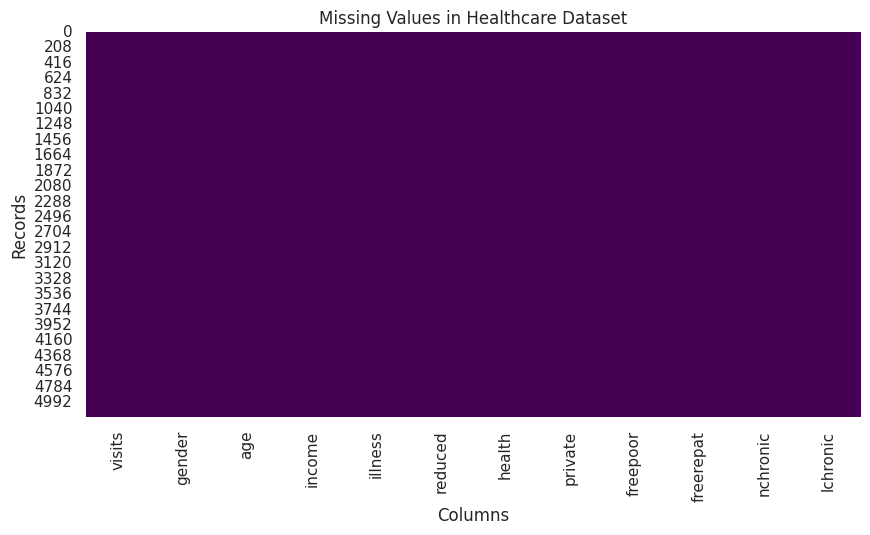

In [35]:
# Checking Missing Values and Duplicates

print("Missing values in each column:")
display(df.isnull().sum())

print("Total missing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values in Healthcare Dataset")
plt.xlabel("Columns")
plt.ylabel("Records")
plt.show()

Gender distribution:


,count
gender,
female,2702
male,2488


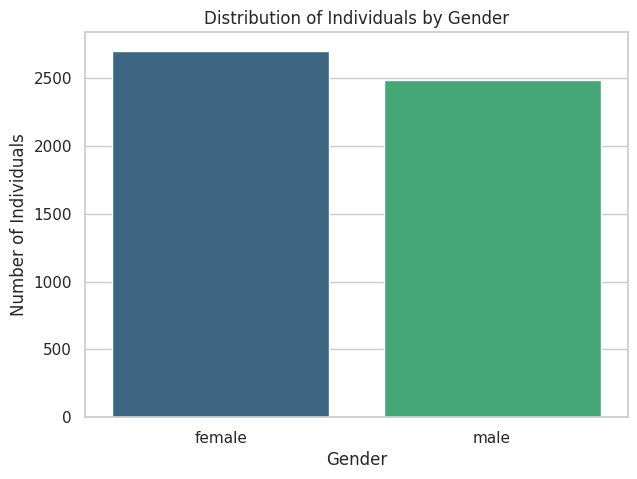

In [36]:
# Analysing Gender Distribution

gender_counts = df["gender"].value_counts()

print("Gender distribution:")
display(gender_counts)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender",
    hue="gender",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Individuals by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Individuals")
plt.show()

Age statistics:


,age
count,5190.000000
mean,0.406385
std,0.204782
min,0.190000
25%,0.220000
50%,0.320000
75%,0.620000
max,0.720000


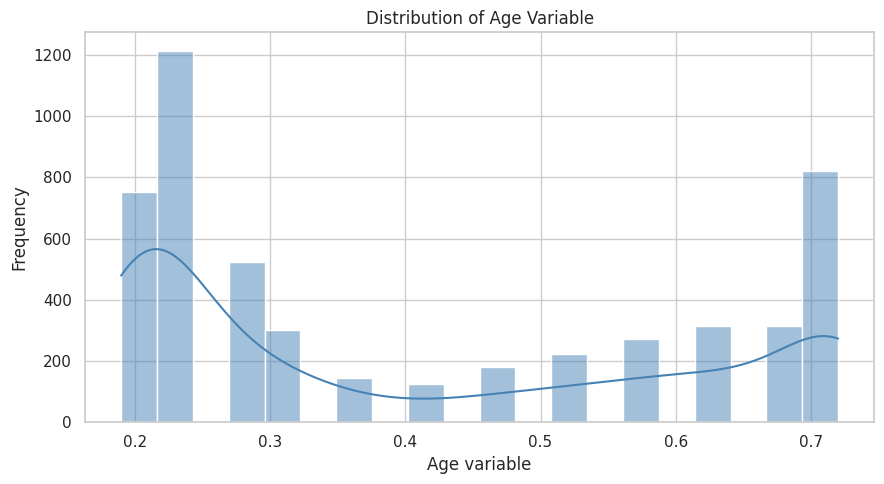

In [37]:
# Analysing Age Distribution

print("Age statistics:")
display(df["age"].describe())

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Age Variable")
plt.xlabel("Age variable")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Doctor visit frequency:


,count
visits,
0,4141
1,782
2,174
3,30
4,24
5,9
6,12
7,12
8,5


Average doctor visits: 0.3017341040462428
Median doctor visits: 0.0
Maximum doctor visits: 9


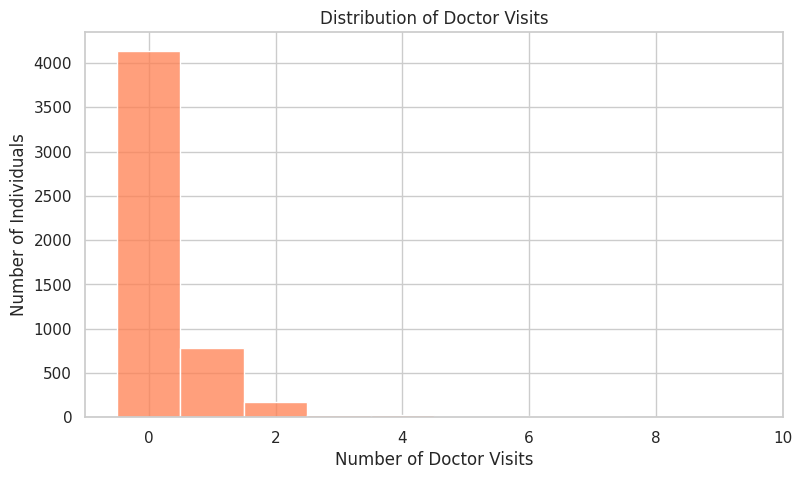

In [38]:
# Analysing Doctor Visit Distribution

print("Doctor visit frequency:")
display(df["visits"].value_counts().sort_index())

print("Average doctor visits:", df["visits"].mean())
print("Median doctor visits:", df["visits"].median())
print("Maximum doctor visits:", df["visits"].max())

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="visits",
    discrete=True,
    color="coral"
)

plt.title("Distribution of Doctor Visits")
plt.xlabel("Number of Doctor Visits")
plt.ylabel("Number of Individuals")
plt.show()

Doctor visits by gender:


,gender,count,mean,median,sum
0,female,2702,0.361954,0.0,978
1,male,2488,0.236334,0.0,588


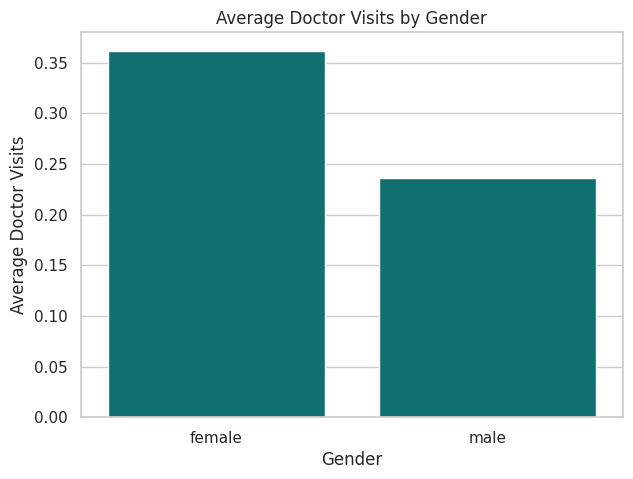

In [39]:
# Comparing Doctor Visits by Gender

gender_visits = (
    df.groupby("gender")["visits"]
    .agg(["count", "mean", "median", "sum"])
    .reset_index()
)

print("Doctor visits by gender:")
display(gender_visits)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_visits,
    x="gender",
    y="mean",
    color="teal"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Doctor Visits")
plt.show()

,illness,count,mean,median
0,0,1554,0.078507,0.0
1,1,1638,0.295482,0.0
2,2,946,0.403805,0.0
3,3,542,0.420664,0.0
4,4,274,0.576642,0.0
5,5,236,0.813559,0.0


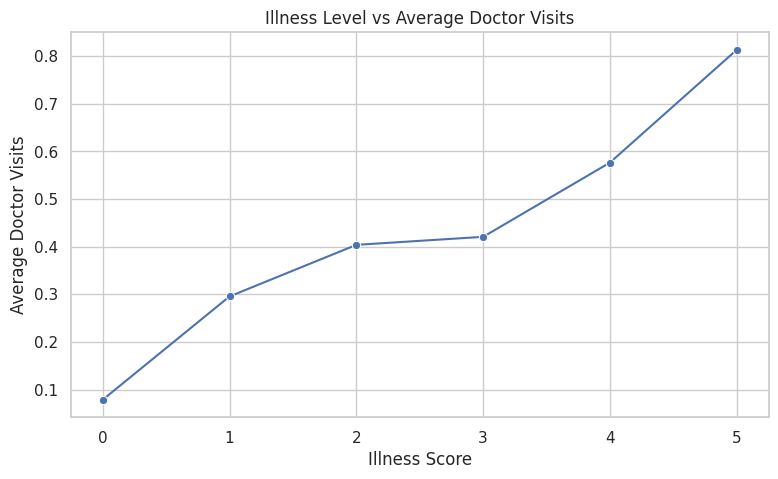

In [40]:
# Analysing Illness Levels and Doctor Visits

illness_analysis = (
    df.groupby("illness")["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(illness_analysis)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)

plt.title("Illness Level vs Average Doctor Visits")
plt.xlabel("Illness Score")
plt.ylabel("Average Doctor Visits")
plt.show()

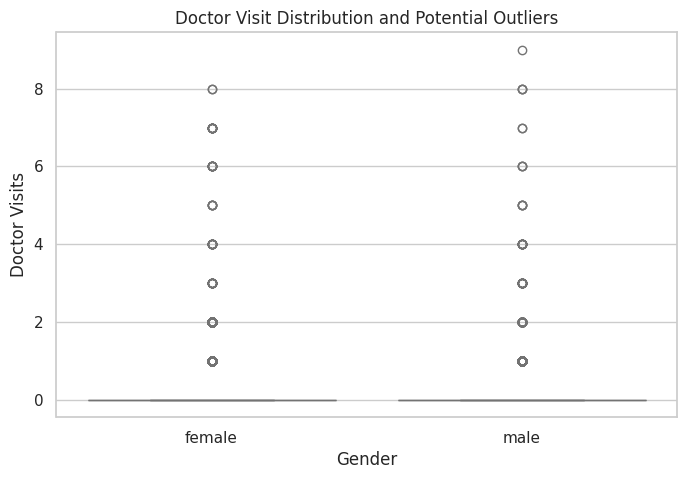

In [41]:
# Identifying Outliers Using a Box Plot

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="gender",
    y="visits",
    hue="gender",
    palette="pastel",
    legend=False
)

plt.title("Doctor Visit Distribution and Potential Outliers")
plt.xlabel("Gender")
plt.ylabel("Doctor Visits")
plt.show()

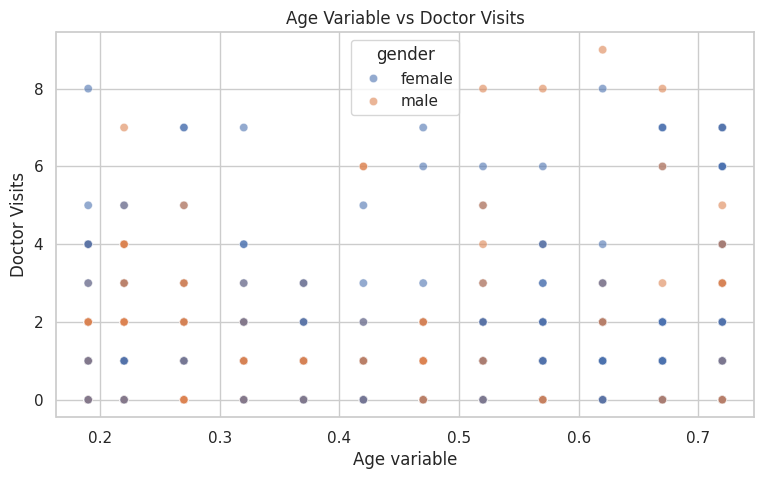

In [42]:
# Examining Age and Doctor Visits

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="visits",
    hue="gender",
    alpha=0.6
)

plt.title("Age Variable vs Doctor Visits")
plt.xlabel("Age variable")
plt.ylabel("Doctor Visits")
plt.show()

Income statistics:


,income
count,5190.000000
mean,0.583160
std,0.368907
min,0.000000
25%,0.250000
50%,0.550000
75%,0.900000
max,1.500000


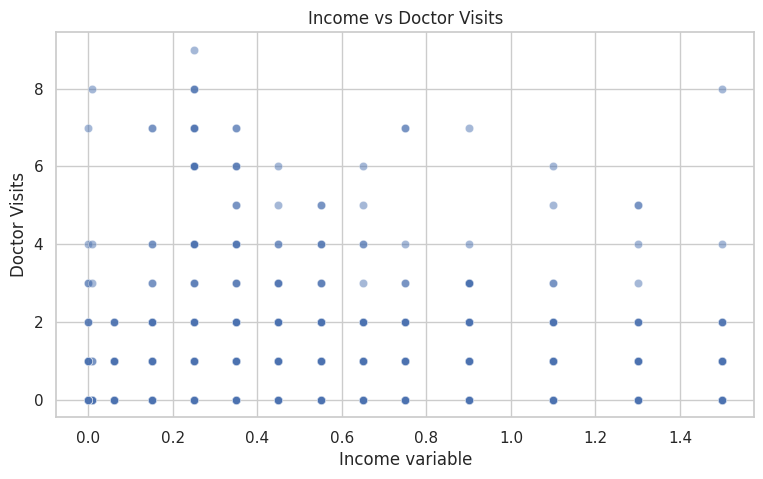

Correlation between income and visits:
-0.07683982934758851


In [43]:
# Analysing Income and Doctor Visits

print("Income statistics:")
display(df["income"].describe())

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="income",
    y="visits",
    alpha=0.5
)

plt.title("Income vs Doctor Visits")
plt.xlabel("Income variable")
plt.ylabel("Doctor Visits")
plt.show()

print("Correlation between income and visits:")
print(df["income"].corr(df["visits"]))

,health,count,mean,median
0,0,3026,0.199273,0.0
1,1,823,0.335358,0.0
2,2,446,0.381166,0.0
3,3,273,0.417582,0.0
4,4,187,0.534759,0.0
5,5,132,0.530303,0.0
6,6,104,0.625000,0.0
7,7,61,0.918033,0.0
8,8,42,0.476190,0.0
9,9,32,0.656250,0.0


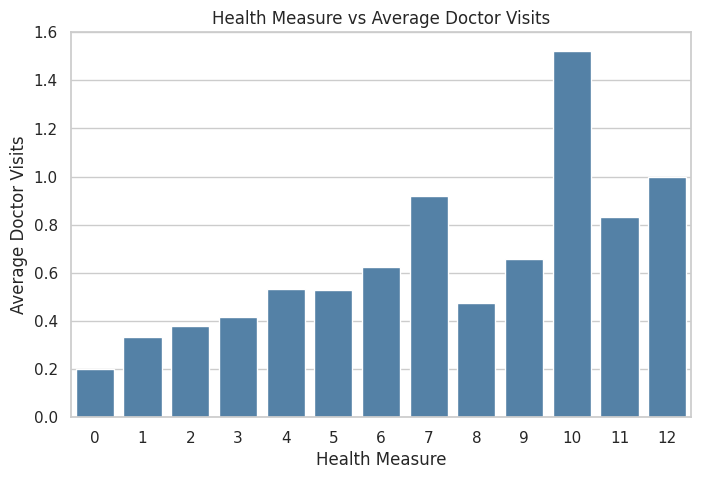

In [44]:
# Analysing Health Status and Doctor Visits

health_analysis = (
    df.groupby("health")["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(health_analysis)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=health_analysis,
    x="health",
    y="mean",
    color="steelblue"
)

plt.title("Health Measure vs Average Doctor Visits")
plt.xlabel("Health Measure")
plt.ylabel("Average Doctor Visits")
plt.show()


Distribution of private:


,count
private,
no,2892
yes,2298


Average visits by private:


,private,count,mean,median
0,no,2892,0.307400,0.0
1,yes,2298,0.294604,0.0


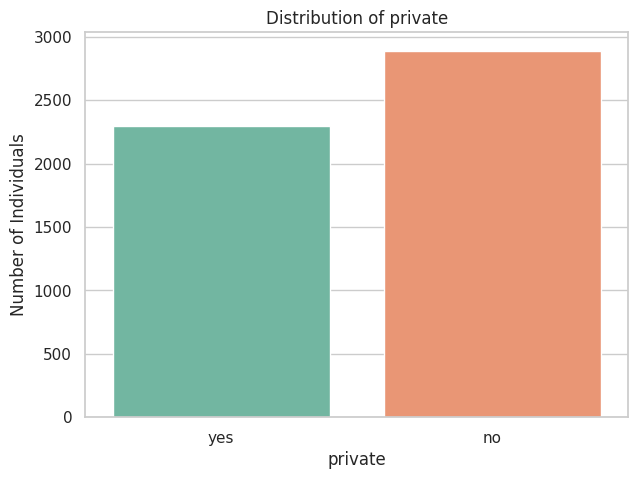


Distribution of freepoor:


,count
freepoor,
no,4968
yes,222


Average visits by freepoor:


,freepoor,count,mean,median
0,no,4968,0.308172,0.0
1,yes,222,0.157658,0.0


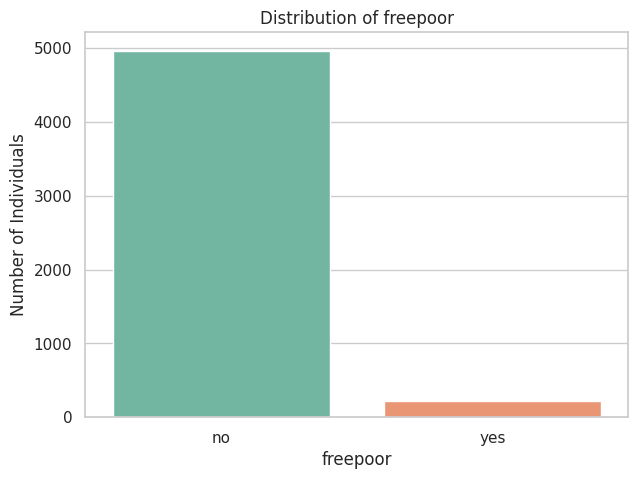


Distribution of freerepat:


,count
freerepat,
no,4099
yes,1091


Average visits by freerepat:


,freerepat,count,mean,median
0,no,4099,0.257868,0.0
1,yes,1091,0.466544,0.0


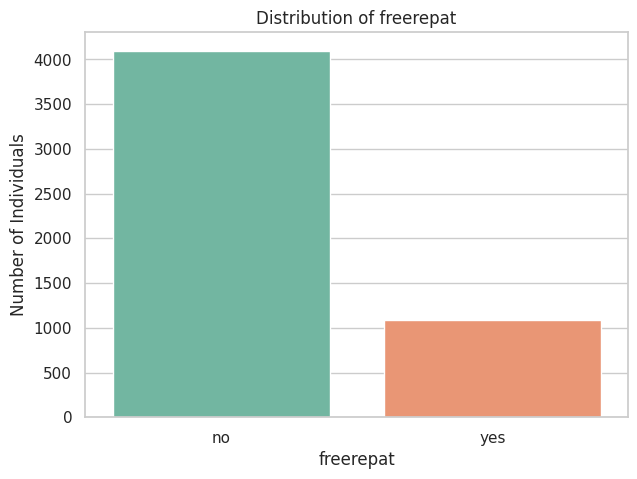

In [45]:
# Analysing Insurance Categories

insurance_columns = [
    "private",
    "freepoor",
    "freerepat"
]

for col in insurance_columns:
    print(f"\nDistribution of {col}:")
    display(df[col].value_counts(dropna=False))

    print(f"Average visits by {col}:")
    display(
        df.groupby(col, dropna=False)["visits"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    plt.figure(figsize=(7, 5))

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette="Set2",
        legend=False
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Individuals")
    plt.show()

,gender,total_reduced_days,average_reduced_days,average_visits
0,female,2636,0.975574,0.361954
1,male,1837,0.738344,0.236334


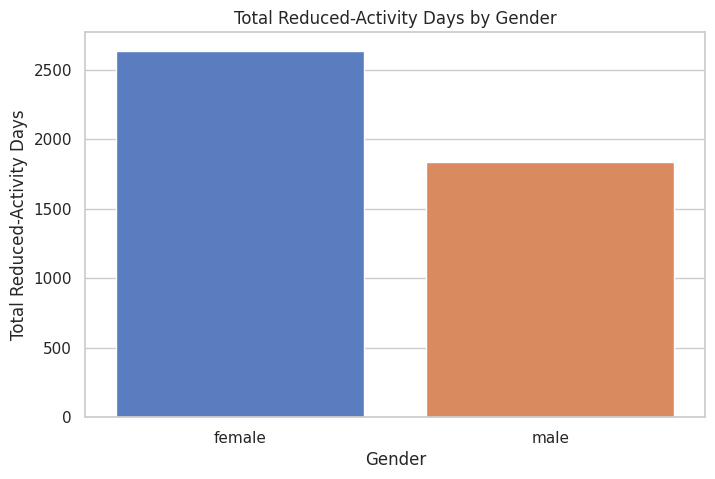

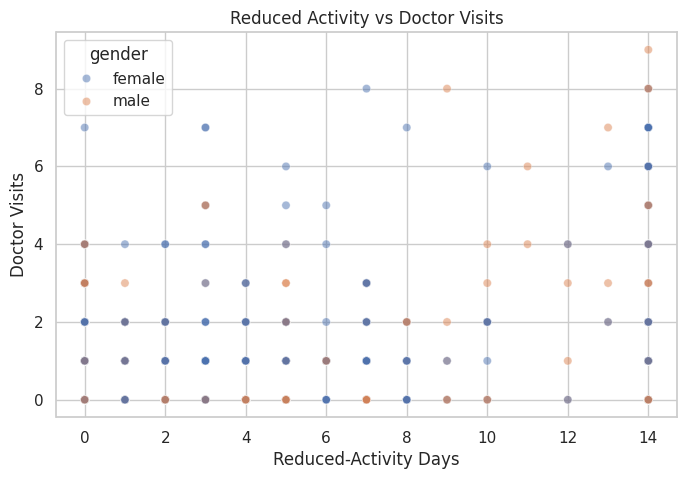

In [46]:
# Analysing Reduced Activity by Gender

reduced_analysis = (
    df.groupby("gender")
    .agg(
        total_reduced_days=("reduced", "sum"),
        average_reduced_days=("reduced", "mean"),
        average_visits=("visits", "mean")
    )
    .reset_index()
)

display(reduced_analysis)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=reduced_analysis,
    x="gender",
    y="total_reduced_days",
    hue="gender",
    palette="muted",
    legend=False
)

plt.title("Total Reduced-Activity Days by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Reduced-Activity Days")
plt.show()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="reduced",
    y="visits",
    hue="gender",
    alpha=0.5
)

plt.title("Reduced Activity vs Doctor Visits")
plt.xlabel("Reduced-Activity Days")
plt.ylabel("Doctor Visits")
plt.show()


Distribution of nchronic:


,count
nchronic,
no,3098
yes,2092


Average visits by nchronic:


,nchronic,count,mean,median
0,no,3098,0.272111,0.0
1,yes,2092,0.345602,0.0


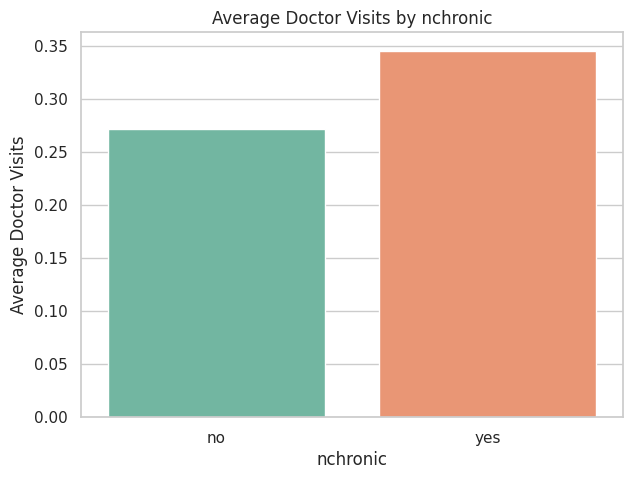


Distribution of lchronic:


,count
lchronic,
no,4585
yes,605


Average visits by lchronic:


,lchronic,count,mean,median
0,no,4585,0.261941,0.0
1,yes,605,0.603306,0.0


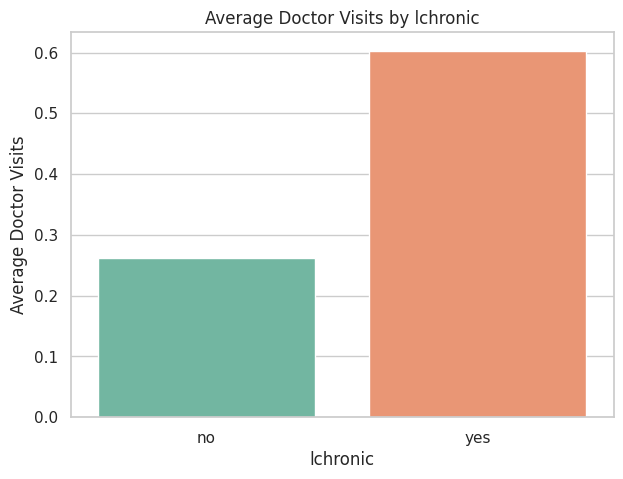

In [47]:
# Examining Chronic Condition Indicators

chronic_columns = ["nchronic", "lchronic"]

for col in chronic_columns:
    print(f"\nDistribution of {col}:")
    display(df[col].value_counts(dropna=False))

    print(f"Average visits by {col}:")
    display(
        df.groupby(col, dropna=False)["visits"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    plt.figure(figsize=(7, 5))

    sns.barplot(
        data=df,
        x=col,
        y="visits",
        hue=col,
        palette="Set2",
        errorbar=None,
        legend=False
    )

    plt.title(f"Average Doctor Visits by {col}")
    plt.xlabel(col)
    plt.ylabel("Average Doctor Visits")
    plt.show()

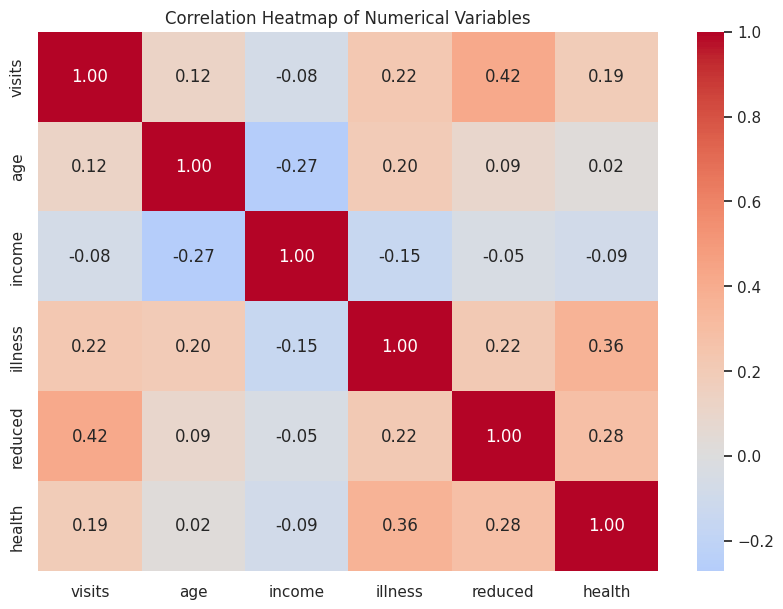

In [48]:
# Creating a Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [49]:
# Generating the Overall Analysis Summary

print("=" * 50)
print("HEALTHCARE ANALYTICS FOR DOCTOR VISITS")
print("OVERALL ANALYSIS SUMMARY")
print("=" * 50)

print("\nDataset Overview")
print("Total records:", len(df))
print("Total variables:", len(df.columns))
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate records:", df.duplicated().sum())

print("\nDoctor Visit Statistics")
print("Mean:", round(df["visits"].mean(), 2))
print("Median:", df["visits"].median())
print("Minimum:", df["visits"].min())
print("Maximum:", df["visits"].max())

print("\nAverage Doctor Visits by Gender")
display(df.groupby("gender")["visits"].mean().round(2))

print("\nAverage Doctor Visits by Illness Level")
display(df.groupby("illness")["visits"].mean().round(2))

print("\nAverage Doctor Visits by Health Measure")
display(df.groupby("health")["visits"].mean().round(2))

print("\nCorrelation Between Numerical Variables")
display(correlation_matrix)

HEALTHCARE ANALYTICS FOR DOCTOR VISITS
OVERALL ANALYSIS SUMMARY

Dataset Overview
Total records: 5190
Total variables: 12
Total missing values: 0
Duplicate records: 1320

Doctor Visit Statistics
Mean: 0.3
Median: 0.0
Minimum: 0
Maximum: 9

Average Doctor Visits by Gender


,visits
gender,
female,0.36
male,0.24



Average Doctor Visits by Illness Level


,visits
illness,
0,0.08
1,0.30
2,0.40
3,0.42
4,0.58
5,0.81



Average Doctor Visits by Health Measure


,visits
health,
0,0.20
1,0.34
2,0.38
3,0.42
4,0.53
5,0.53
6,0.62
7,0.92
8,0.48



Correlation Between Numerical Variables


,visits,age,income,illness,reduced,health
visits,1.000000,0.124537,-0.076840,0.223552,0.418954,0.193272
age,0.124537,1.000000,-0.271073,0.204984,0.094745,0.018616
income,-0.076840,-0.271073,1.000000,-0.148812,-0.047545,-0.085790
illness,0.223552,0.204984,-0.148812,1.000000,0.218116,0.360110
reduced,0.418954,0.094745,-0.047545,0.218116,1.000000,0.280208
health,0.193272,0.018616,-0.085790,0.360110,0.280208,1.000000


# Conclusion
This project analysed the Healthcare Analytics for Doctor Visits dataset
using Python, Pandas, Matplotlib, and Seaborn.

The analysis explored doctor-visit patterns and examined their relationships
with demographic factors such as age and gender, as well as illness,
income, health status, insurance coverage, reduced activity, and chronic
conditions.

Data cleaning, descriptive statistics, and visualizations helped summarize
the dataset and identify patterns and relationships among the variables.

Overall, the project demonstrates how data analysis can help us better
understand healthcare utilization and the factors associated with doctor
visits. However, the observed relationships do not necessarily imply
causation.

The findings are limited to the available dataset and its variables.
Further analysis with additional data could provide deeper insights into
healthcare-seeking behaviour.